In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [10]:
import pandas as pd
df = pd.read_csv("vanilla_convertibles_data_enhanced.csv")

In [11]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=["price_convertible", "price_normalized"])
y = df[["price_normalized"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)

In [12]:
from sklearn.preprocessing import QuantileTransformer

scaler_X = QuantileTransformer(output_distribution="normal", random_state=42)
scaler_y = QuantileTransformer(output_distribution="normal", random_state=42)

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_val = scaler_y.transform(y_val)

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

In [14]:
INPUT_DIM = X_train.shape[1]
OUTPUT_DIM = y_train.shape[1]

WIDTH = 528
DEPTHS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

BATCH_SIZE = 1024
LR = 1e-3
EPOCHS = 200
PATIENCE = 10

SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Input: {INPUT_DIM} | Output: {OUTPUT_DIM}")

Device: cpu | Input: 25 | Output: 1


In [15]:
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE)

In [16]:
from nn_build import build_mlp

results = []

for depth in DEPTHS:
    print(f"\n{'='*40}")
    print(f"Depth={depth}, Width={WIDTH}")
    print(f"{'='*40}")

    torch.manual_seed(SEED)
    model = build_mlp(INPUT_DIM, OUTPUT_DIM, depth, WIDTH, batch_norm=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict().copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or wait == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

        if wait >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    results.append({"depth": depth, "best_val_loss": best_val, "best_state": best_state})
    print(f"  Best Val Loss: {best_val:.6f}")


Depth=1, Width=528
  Epoch   1 | Train: 0.158352 | Val: 0.124250 | Wait: 0
  Epoch   2 | Train: 0.119739 | Val: 0.108581 | Wait: 0
  Epoch   3 | Train: 0.108942 | Val: 0.102135 | Wait: 0
  Epoch   4 | Train: 0.097745 | Val: 0.088665 | Wait: 0
  Epoch   5 | Train: 0.091181 | Val: 0.084475 | Wait: 0
  Epoch   6 | Train: 0.088065 | Val: 0.080683 | Wait: 0
  Epoch   8 | Train: 0.081474 | Val: 0.075212 | Wait: 0
  Epoch  10 | Train: 0.070362 | Val: 0.060883 | Wait: 0
  Epoch  11 | Train: 0.063561 | Val: 0.055391 | Wait: 0
  Epoch  12 | Train: 0.055175 | Val: 0.044932 | Wait: 0
  Epoch  13 | Train: 0.049452 | Val: 0.044562 | Wait: 0
  Epoch  14 | Train: 0.045619 | Val: 0.035309 | Wait: 0
  Epoch  16 | Train: 0.038709 | Val: 0.030714 | Wait: 0
  Epoch  17 | Train: 0.036634 | Val: 0.027252 | Wait: 0
  Epoch  18 | Train: 0.034271 | Val: 0.026446 | Wait: 0
  Epoch  20 | Train: 0.032298 | Val: 0.023694 | Wait: 0
  Epoch  21 | Train: 0.031604 | Val: 0.021766 | Wait: 0
  Epoch  24 | Train: 0.02928

In [17]:
summary = pd.DataFrame([(r["depth"], r["best_val_loss"]) for r in results],
                        columns=["depth", "best_val_loss"])
print(summary.to_string(index=False))

best = summary.loc[summary["best_val_loss"].idxmin()]
print(f"\nBest depth: {int(best['depth'])} with val loss: {best['best_val_loss']:.6f}")

 depth  best_val_loss
     1       0.014311
     2       0.013988
     3       0.014010
     4       0.011680
     5       0.010877
     6       0.010221
     7       0.012368
     8       0.011386
     9       0.011000
    10       0.010512

Best depth: 6 with val loss: 0.010221


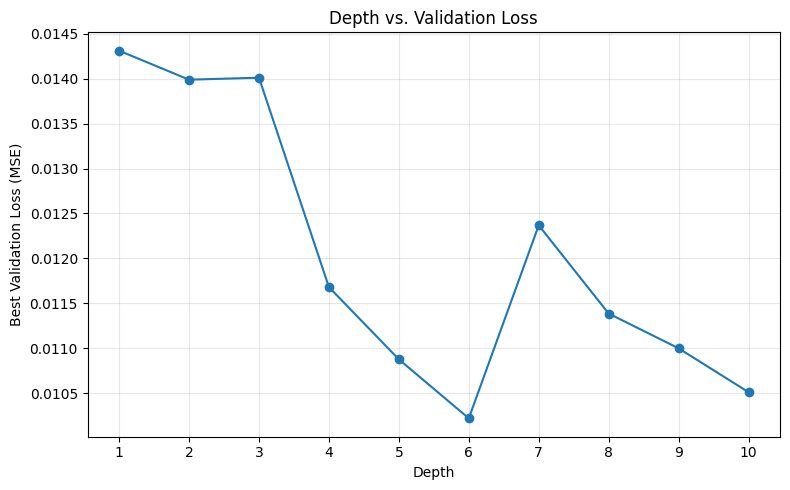

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(summary["depth"], summary["best_val_loss"], marker="o")
plt.xlabel("Depth")
plt.ylabel("Best Validation Loss (MSE)")
plt.title("Depth vs. Validation Loss")
plt.xticks(summary["depth"].astype(int))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
DEPTH = 6
WIDTHS = [32, 64, 128, 256, 512, 1024, 2048, 2560, 3072]

In [20]:
results = []

for width in WIDTHS:
    print(f"\n{'='*40}")
    print(f"Depth={DEPTH}, Width={width}")
    print(f"{'='*40}")

    torch.manual_seed(SEED)
    model = build_mlp(INPUT_DIM, OUTPUT_DIM, DEPTH, width, batch_norm=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict().copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or wait == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

        if wait >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    results.append({"width": width, "best_val_loss": best_val, "best_state": best_state})
    print(f"  Best Val Loss: {best_val:.6f}")


Depth=6, Width=32
  Epoch   1 | Train: 0.089045 | Val: 0.033108 | Wait: 0
  Epoch   2 | Train: 0.036990 | Val: 0.026338 | Wait: 0
  Epoch   3 | Train: 0.036533 | Val: 0.015075 | Wait: 0
  Epoch   5 | Train: 0.032253 | Val: 0.014366 | Wait: 0
  Epoch   7 | Train: 0.030440 | Val: 0.012102 | Wait: 0
  Epoch  10 | Train: 0.031329 | Val: 0.025290 | Wait: 3
  Epoch  16 | Train: 0.028746 | Val: 0.011782 | Wait: 0
  Epoch  20 | Train: 0.028420 | Val: 0.016358 | Wait: 4
  Epoch  21 | Train: 0.028070 | Val: 0.011061 | Wait: 0
  Epoch  23 | Train: 0.027088 | Val: 0.010958 | Wait: 0
  Epoch  24 | Train: 0.025280 | Val: 0.010926 | Wait: 0
  Epoch  27 | Train: 0.024780 | Val: 0.009759 | Wait: 0
  Epoch  29 | Train: 0.022729 | Val: 0.008871 | Wait: 0
  Epoch  30 | Train: 0.025314 | Val: 0.013845 | Wait: 1
  Early stop at epoch 39
  Best Val Loss: 0.008871

Depth=6, Width=64
  Epoch   1 | Train: 0.073914 | Val: 0.026507 | Wait: 0
  Epoch   2 | Train: 0.039851 | Val: 0.019156 | Wait: 0
  Epoch   6 | T

In [21]:
width_summary = pd.DataFrame([(r["width"], r["best_val_loss"]) for r in results],
                              columns=["width", "best_val_loss"])
print(width_summary.to_string(index=False))

best_w = width_summary.loc[width_summary["best_val_loss"].idxmin()]
print(f"\nBest width: {int(best_w['width'])} with val loss: {best_w['best_val_loss']:.6f}")

 width  best_val_loss
    32       0.008871
    64       0.010216
   128       0.009779
   256       0.010331
   512       0.009850
  1024       0.009322
  2048       0.012298
  2560       0.009434
  3072       0.010819

Best width: 32 with val loss: 0.008871


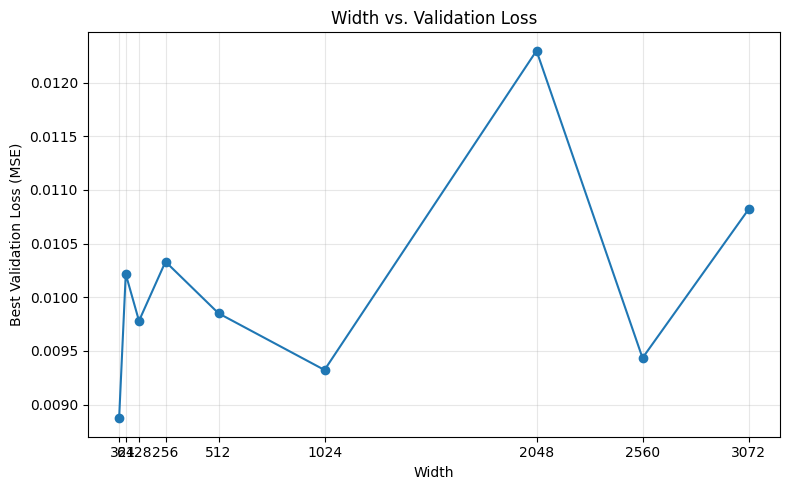

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(width_summary["width"], width_summary["best_val_loss"], marker="o")
plt.xlabel("Width")
plt.ylabel("Best Validation Loss (MSE)")
plt.title("Width vs. Validation Loss")
plt.xticks(width_summary["width"].astype(int))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
GRID_DEPTHS = [6, 7, 8, 9, 10]
GRID_WIDTHS = [32, 512, 768, 1024, 1536, 2560]
print(f"Grid search: {len(GRID_DEPTHS)} depths x {len(GRID_WIDTHS)} widths = {len(GRID_DEPTHS)*len(GRID_WIDTHS)} combinations")

Grid search: 5 depths x 6 widths = 30 combinations


In [25]:
grid_results = []

for depth in GRID_DEPTHS:
    for width in GRID_WIDTHS:
        print(f"\n{'='*40}")
        print(f"Depth={depth}, Width={width}")
        print(f"{'='*40}")

        torch.manual_seed(SEED)
        model = build_mlp(INPUT_DIM, OUTPUT_DIM, depth, width, batch_norm=True).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
        criterion = nn.MSELoss()

        best_val = float("inf")
        best_state = None
        wait = 0

        for epoch in range(EPOCHS):
            model.train()
            train_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item() * len(xb)
            train_loss /= len(train_loader.dataset)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += criterion(model(xb), yb).item() * len(xb)
            val_loss /= len(val_loader.dataset)

            if val_loss < best_val:
                best_val = val_loss
                best_state = model.state_dict().copy()
                wait = 0
            else:
                wait += 1

            if (epoch + 1) % 10 == 0 or wait == 0:
                print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

            if wait >= PATIENCE:
                print(f"  Early stop at epoch {epoch+1}")
                break

        grid_results.append({"depth": depth, "width": width, "best_val_loss": best_val, "best_state": best_state})
        print(f"  Best Val Loss: {best_val:.6f}")


Depth=6, Width=32
  Epoch   1 | Train: 0.089045 | Val: 0.033108 | Wait: 0
  Epoch   2 | Train: 0.036990 | Val: 0.026338 | Wait: 0
  Epoch   3 | Train: 0.036533 | Val: 0.015075 | Wait: 0
  Epoch   5 | Train: 0.032253 | Val: 0.014366 | Wait: 0
  Epoch   7 | Train: 0.030440 | Val: 0.012102 | Wait: 0
  Epoch  10 | Train: 0.031329 | Val: 0.025290 | Wait: 3
  Epoch  16 | Train: 0.028746 | Val: 0.011782 | Wait: 0
  Epoch  20 | Train: 0.028420 | Val: 0.016358 | Wait: 4
  Epoch  21 | Train: 0.028070 | Val: 0.011061 | Wait: 0
  Epoch  23 | Train: 0.027088 | Val: 0.010958 | Wait: 0
  Epoch  24 | Train: 0.025280 | Val: 0.010926 | Wait: 0
  Epoch  27 | Train: 0.024780 | Val: 0.009759 | Wait: 0
  Epoch  29 | Train: 0.022729 | Val: 0.008871 | Wait: 0
  Epoch  30 | Train: 0.025314 | Val: 0.013845 | Wait: 1
  Early stop at epoch 39
  Best Val Loss: 0.008871

Depth=6, Width=512
  Epoch   1 | Train: 0.079572 | Val: 0.056486 | Wait: 0
  Epoch   2 | Train: 0.047546 | Val: 0.041648 | Wait: 0
  Epoch   3 | 

In [26]:
grid_df = pd.DataFrame([(r["depth"], r["width"], r["best_val_loss"]) for r in grid_results],
                       columns=["depth", "width", "best_val_loss"])
print(grid_df.sort_values("best_val_loss").to_string(index=False))

best_g = grid_df.loc[grid_df["best_val_loss"].idxmin()]
print(f"\nBest: depth={int(best_g['depth'])}, width={int(best_g['width'])}, val loss={best_g['best_val_loss']:.6f}")

 depth  width  best_val_loss
     6     32       0.008871
     6   1024       0.009322
     6   2560       0.009434
    10   1536       0.009560
    10   1024       0.009788
     6    512       0.009850
     7    512       0.009995
    10    512       0.010038
     7   1024       0.010215
     8   2560       0.010551
    10     32       0.010584
     7    768       0.010644
     7     32       0.010760
     9    768       0.010997
     9    512       0.011204
     8   1024       0.011566
     6    768       0.011707
     7   1536       0.011851
     8   1536       0.012150
     6   1536       0.012261
     9   2560       0.012366
     9   1536       0.012510
     7   2560       0.012791
     8     32       0.013760
     9     32       0.013885
    10   2560       0.014140
     8    512       0.014212
     9   1024       0.014735
     8    768       0.016426
    10    768       0.016572

Best: depth=6, width=32, val loss=0.008871


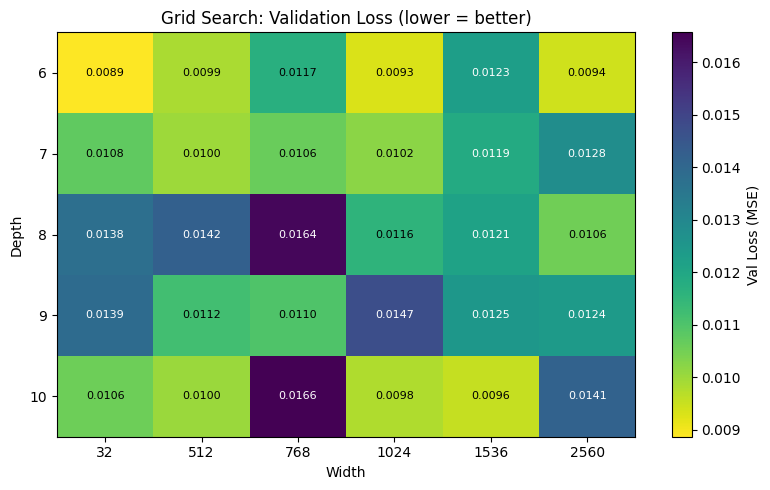

In [27]:
import numpy as np

heatmap = grid_df.pivot(index="depth", columns="width", values="best_val_loss")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap.values, cmap="viridis_r", aspect="auto")

ax.set_xticks(range(len(GRID_WIDTHS)))
ax.set_xticklabels(GRID_WIDTHS)
ax.set_yticks(range(len(GRID_DEPTHS)))
ax.set_yticklabels(GRID_DEPTHS)
ax.set_xlabel("Width")
ax.set_ylabel("Depth")
ax.set_title("Grid Search: Validation Loss (lower = better)")

for i in range(len(GRID_DEPTHS)):
    for j in range(len(GRID_WIDTHS)):
        val = heatmap.values[i, j]
        ax.text(j, i, f"{val:.4f}", ha="center", va="center", fontsize=8,
                color="white" if val > heatmap.values.mean() else "black")

fig.colorbar(im, ax=ax, label="Val Loss (MSE)")
plt.tight_layout()
plt.show()

In [30]:
BEST_DEPTH = 6
BEST_WIDTH = 32

LRS = [5e-4, 1e-3, 5e-3, 1e-2]
BATCH_SIZES = [256, 512, 1024]
WEIGHT_DECAYS = [1e-4, 1e-3, 1e-2]

print(f"HP sweep: {len(LRS)} LRs x {len(BATCH_SIZES)} batch sizes x {len(WEIGHT_DECAYS)} weight decays = {len(LRS)*len(BATCH_SIZES)*len(WEIGHT_DECAYS)} runs")
print(f"Architecture: depth={BEST_DEPTH}, width={BEST_WIDTH}")
print("Scheduler: ReduceLROnPlateau (always on)")

HP sweep: 4 LRs x 3 batch sizes x 3 weight decays = 36 runs
Architecture: depth=6, width=32
Scheduler: ReduceLROnPlateau (always on)


In [31]:
hp_results = []

for bs in BATCH_SIZES:
    t_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=bs, shuffle=True)
    v_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=bs)

    for lr in LRS:
        for wd in WEIGHT_DECAYS:
            print(f"\n{'='*50}")
            print(f"BS={bs}, LR={lr}, WD={wd}")
            print(f"{'='*50}")

            torch.manual_seed(SEED)
            model = build_mlp(INPUT_DIM, OUTPUT_DIM, BEST_DEPTH, BEST_WIDTH, batch_norm=True).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
            criterion = nn.MSELoss()

            best_val = float("inf")
            best_state = None
            wait = 0

            for epoch in range(EPOCHS):
                model.train()
                train_loss = 0.0
                for xb, yb in t_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    pred = model(xb)
                    loss = criterion(pred, yb)
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    train_loss += loss.item() * len(xb)
                train_loss /= len(t_loader.dataset)

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for xb, yb in v_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        val_loss += criterion(model(xb), yb).item() * len(xb)
                val_loss /= len(v_loader.dataset)

                scheduler.step(val_loss)

                if val_loss < best_val:
                    best_val = val_loss
                    best_state = model.state_dict().copy()
                    wait = 0
                else:
                    wait += 1

                if (epoch + 1) % 10 == 0 or wait == 0:
                    print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

                if wait >= PATIENCE:
                    print(f"  Early stop at epoch {epoch+1}")
                    break

            hp_results.append({"batch_size": bs, "lr": lr, "weight_decay": wd, "best_val_loss": best_val, "best_state": best_state})
            print(f"  Best Val Loss: {best_val:.6f}")


BS=256, LR=0.0005, WD=0.0001
  Epoch   1 | Train: 0.095454 | Val: 0.025516 | Wait: 0
  Epoch   3 | Train: 0.056628 | Val: 0.020834 | Wait: 0
  Epoch   4 | Train: 0.055263 | Val: 0.019137 | Wait: 0
  Epoch   5 | Train: 0.050667 | Val: 0.014561 | Wait: 0
  Epoch  10 | Train: 0.044601 | Val: 0.014813 | Wait: 5
  Epoch  13 | Train: 0.037978 | Val: 0.013205 | Wait: 0
  Epoch  14 | Train: 0.038363 | Val: 0.012545 | Wait: 0
  Epoch  16 | Train: 0.036710 | Val: 0.009638 | Wait: 0
  Epoch  20 | Train: 0.037807 | Val: 0.014829 | Wait: 4
  Epoch  23 | Train: 0.034239 | Val: 0.009113 | Wait: 0
  Epoch  30 | Train: 0.033021 | Val: 0.008213 | Wait: 0
  Epoch  37 | Train: 0.030937 | Val: 0.007727 | Wait: 0
  Epoch  40 | Train: 0.031497 | Val: 0.008115 | Wait: 3
  Early stop at epoch 47
  Best Val Loss: 0.007727

BS=256, LR=0.0005, WD=0.001
  Epoch   1 | Train: 0.095552 | Val: 0.025361 | Wait: 0
  Epoch   3 | Train: 0.056520 | Val: 0.023580 | Wait: 0
  Epoch   4 | Train: 0.054643 | Val: 0.018396 | Wa

In [32]:
hp_df = pd.DataFrame([(r["lr"], r["batch_size"], r["weight_decay"], r["best_val_loss"])
                      for r in hp_results],
                     columns=["lr", "batch_size", "weight_decay", "best_val_loss"])
print(hp_df.sort_values("best_val_loss").to_string(index=False))

best_hp = hp_df.loc[hp_df["best_val_loss"].idxmin()]
print(f"\nBest: LR={best_hp['lr']}, Batch={int(best_hp['batch_size'])}, WD={best_hp['weight_decay']}, Val Loss={best_hp['best_val_loss']:.6f}")

    lr  batch_size  weight_decay  best_val_loss
0.0005        1024        0.0100       0.004308
0.0005        1024        0.0001       0.004868
0.0005         512        0.0010       0.005537
0.0050        1024        0.0001       0.005942
0.0010         512        0.0100       0.005984
0.0010        1024        0.0100       0.006126
0.0010        1024        0.0010       0.006130
0.0005        1024        0.0010       0.006182
0.0010        1024        0.0001       0.006206
0.0100        1024        0.0100       0.006650
0.0010         512        0.0010       0.006781
0.0005         512        0.0100       0.006983
0.0005         256        0.0100       0.007134
0.0005         512        0.0001       0.007141
0.0050        1024        0.0010       0.007271
0.0010         512        0.0001       0.007410
0.0050         256        0.0010       0.007424
0.0050         512        0.0100       0.007687
0.0005         256        0.0001       0.007727
0.0100         512        0.0100       0

/var/folders/t7/fntycq1j1qj6w3tkrbztnsbw0000gp/T/ipykernel_59930/900486857.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


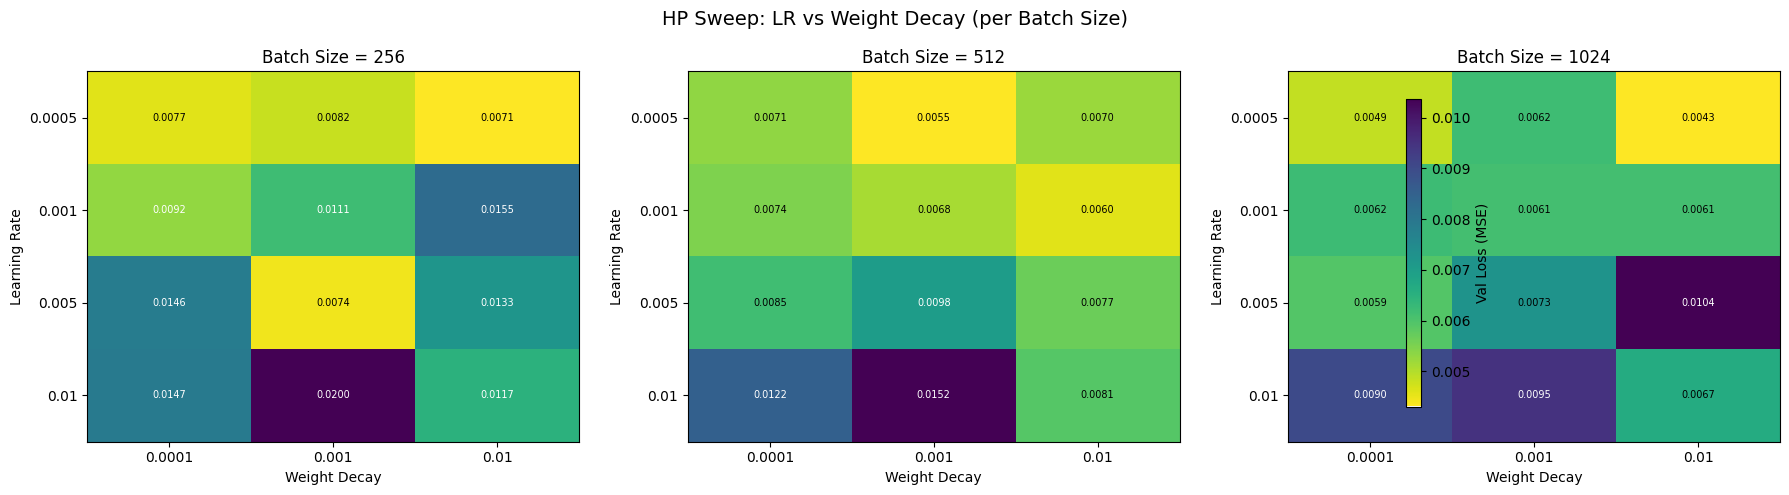

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, bs in enumerate(BATCH_SIZES):
    subset = hp_df[hp_df["batch_size"] == bs]
    hm = subset.pivot(index="lr", columns="weight_decay", values="best_val_loss")

    im = axes[i].imshow(hm.values, cmap="viridis_r", aspect="auto")
    axes[i].set_xticks(range(len(WEIGHT_DECAYS)))
    axes[i].set_xticklabels(WEIGHT_DECAYS)
    axes[i].set_yticks(range(len(LRS)))
    axes[i].set_yticklabels(LRS)
    axes[i].set_xlabel("Weight Decay")
    axes[i].set_ylabel("Learning Rate")
    axes[i].set_title(f"Batch Size = {bs}")

    for r in range(len(LRS)):
        for c in range(len(WEIGHT_DECAYS)):
            val = hm.values[r, c]
            axes[i].text(c, r, f"{val:.4f}", ha="center", va="center", fontsize=7,
                         color="white" if val > hp_df["best_val_loss"].mean() else "black")

fig.colorbar(im, ax=axes, label="Val Loss (MSE)", shrink=0.8)
fig.suptitle("HP Sweep: LR vs Weight Decay (per Batch Size)", fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
best_idx = hp_df["best_val_loss"].idxmin()
best_state = hp_results[best_idx]["best_state"]

final_model = build_mlp(INPUT_DIM, OUTPUT_DIM, BEST_DEPTH, BEST_WIDTH, batch_norm=True).to(device)
final_model.load_state_dict(best_state)
final_model.eval()
print(f"Loaded best model: LR={hp_df.loc[best_idx, 'lr']}, BS={int(hp_df.loc[best_idx, 'batch_size'])}, WD={hp_df.loc[best_idx, 'weight_decay']}")
print(f"Val loss: {hp_df.loc[best_idx, 'best_val_loss']:.6f}")

Loaded best model: LR=0.0005, BS=1024, WD=0.01
Val loss: 0.004308


In [ ]:
import numpy as np

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    preds_scaled = final_model(X_test_t).cpu().numpy()

preds = scaler_y.inverse_transform(preds_scaled).ravel()
y_true = y_test.values.ravel()

# Convert back to actual price: price_convertible = expm1(price_normalized)
preds_price = np.expm1(preds)
y_true_price = np.expm1(y_true)

mae = np.abs(preds_price - y_true_price).mean()
rmse = np.sqrt(((preds_price - y_true_price) ** 2).mean())

print(f"{'Metric':<10} {'Value':>12}")
print("-" * 24)
print(f"{'MAE':<10} {mae:>12.4f}")
print(f"{'RMSE':<10} {rmse:>12.4f}")

In [36]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true_price, preds_price)

print(f"{'Metric':<10} {'Value':>12}")
print("-" * 24)
print(f"{'R²':<10} {r2:>12.6f}")

Metric            Value
------------------------
R²             0.999963


In [38]:
import matplotlib.pyplot as plt

test_features = df.loc[y_test.index]

analysis = pd.DataFrame({
    "price_true": y_true_price,
    "price_pred": preds_price,
    "price_err": np.abs(preds_price - y_true_price),
    "maturity_years": test_features["maturity_years"].values,
    "log_moneyness": test_features["log_moneyness"].values,
    "credit_spread": test_features["credit_spread"].values,
})

# Price regime buckets (dollar terms)
analysis["price_regime"] = pd.cut(analysis["price_true"],
    bins=[0, 200, 500, 1000, 2000, 6000],
    labels=["< $200", "$200-500", "$500-1k", "$1k-2k", "> $2k"])

# Maturity buckets
analysis["maturity"] = pd.cut(analysis["maturity_years"],
    bins=[0, 2, 5, 7, 10],
    labels=["< 2y", "2-5y", "5-7y", "> 7y"])

# Moneyness buckets
analysis["moneyness"] = pd.cut(analysis["log_moneyness"],
    bins=[-3, 0, 1, 2, 3, 5],
    labels=["OTM", "Near ATM", "Mild ITM", "ITM", "Deep ITM"])

# Credit risk buckets (spread in bps)
analysis["credit_risk"] = pd.cut(analysis["credit_spread"],
    bins=[0, 0.03, 0.06, 0.10, 0.15],
    labels=["Low (<300bp)", "Med (300-600bp)", "High (600-1000bp)", "Very High (>1000bp)"])

print("=== Price Error ($) by Price Regime ===")
regime_stats = analysis.groupby("price_regime", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    R2=("price_true", lambda x: r2_score(
        analysis.loc[x.index, "price_true"], analysis.loc[x.index, "price_pred"]))
).reset_index()
print(regime_stats.to_string(index=False))

print("\n=== Price Error ($) by Maturity ===")
mat_stats = analysis.groupby("maturity", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
).reset_index()
print(mat_stats.to_string(index=False))

print("\n=== Price Error ($) by Moneyness ===")
mon_stats = analysis.groupby("moneyness", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
).reset_index()
print(mon_stats.to_string(index=False))

print("\n=== Price Error ($) by Credit Risk ===")
credit_stats = analysis.groupby("credit_risk", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    R2=("price_true", lambda x: r2_score(
        analysis.loc[x.index, "price_true"], analysis.loc[x.index, "price_pred"]))
).reset_index()
print(credit_stats.to_string(index=False))

=== Price Error ($) by Price Regime ===
Empty DataFrame
Columns: [price_regime, count, MAE, RMSE, R2]
Index: []

=== Price Error ($) by Maturity ===
maturity  count          MAE        RMSE
    < 2y  27967 16159.601142 27910.22447
    2-5y  83425 14946.873827 25687.60456
    5-7y  55377 15036.459725 25709.44641
    > 7y  83231 15288.562623 26074.81622

=== Price Error ($) by Moneyness ===
moneyness  count          MAE         RMSE
      OTM   7786     0.000000     0.000000
 Near ATM  22455   972.521845  1361.909200
 Mild ITM  58351  3230.093509  4658.485489
      ITM  95659 13873.272368 19569.078437
 Deep ITM  65749 34473.746738 44821.033056

=== Price Error ($) by Credit Risk ===
        credit_risk  count          MAE         RMSE       R2
       Low (<300bp)  43153 15767.283401 26461.245089 0.999962
    Med (300-600bp)  51640 14922.706468 25634.862749 0.999964
  High (600-1000bp)  69004 14727.338406 25298.002693 0.999965
Very High (>1000bp)  86203 15507.296708 26756.327004 0.999961


KeyError: 'T'

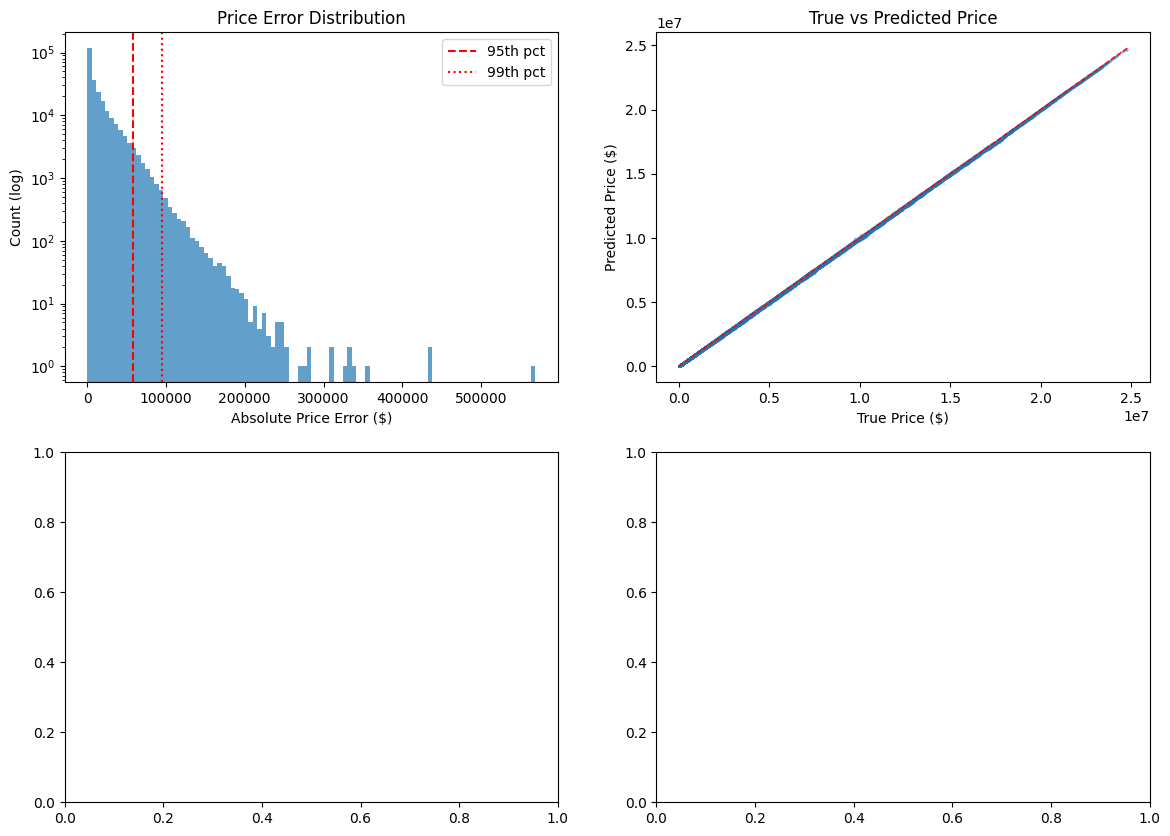

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Error distribution (log scale)
axes[0, 0].hist(analysis["price_err"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Absolute Price Error ($)")
axes[0, 0].set_ylabel("Count (log)")
axes[0, 0].set_title("Price Error Distribution")
axes[0, 0].axvline(analysis["price_err"].quantile(0.95), color="r", ls="--", label="95th pct")
axes[0, 0].axvline(analysis["price_err"].quantile(0.99), color="r", ls=":", label="99th pct")
axes[0, 0].legend()

# 2. True vs Predicted scatter
axes[0, 1].scatter(analysis["price_true"], analysis["price_pred"], s=1, alpha=0.1)
lims = [analysis["price_true"].min(), analysis["price_true"].max()]
axes[0, 1].plot(lims, lims, "r--", lw=1)
axes[0, 1].set_xlabel("True Price ($)")
axes[0, 1].set_ylabel("Predicted Price ($)")
axes[0, 1].set_title("True vs Predicted Price")

# 3. Error vs maturity
axes[1, 0].scatter(analysis["T"], analysis["price_err"], s=1, alpha=0.1)
axes[1, 0].set_xlabel("T (years)")
axes[1, 0].set_ylabel("Absolute Price Error ($)")
axes[1, 0].set_title("Price Error vs Maturity")
axes[1, 0].set_xlim(0, 3)

# 4. Error vs moneyness
axes[1, 1].scatter(analysis["fwd_log_moneyness"], analysis["price_err"], s=1, alpha=0.1)
axes[1, 1].set_xlabel("Fwd Log Moneyness")
axes[1, 1].set_ylabel("Absolute Price Error ($)")
axes[1, 1].set_title("Price Error vs Moneyness")

plt.suptitle("Price Error Analysis ($)", fontsize=14)
plt.tight_layout()
plt.show()